# Разведочный анализ данных: начало

Мы будем работать с датасетом про алмазы - в нем содержатся их различные характеристики, а также стоимость.

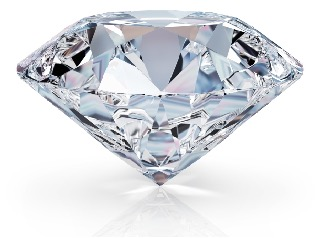

[Интересная статья про качество алмазов](https://www.diamonds.pro/education/diamond-depth-and-table/)

**Цели на сегодня:**

* понять влияние различных характеристик алмазов на их качество и стоимость

* научиться делать разведочный анализ данных

* изучить библиотеки pandas, numpy и matplotlib, seaborn

[Pandas cheatsheet](https://images.datacamp.com/image/upload/v1676302204/Marketing/Blog/Pandas_Cheat_Sheet.pdf)

## Импорт библиотек и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DIAMONDS_DATASET = "/content/drive/MyDrive/data/eda/diamonds_good.csv"

In [5]:
df = pd.read_csv(DIAMONDS_DATASET)

## Описание данных

* `carat` - число каратов алмаза
* `cut` - огранка алмаза
* `color` - цвет алмаза
* `clarity` - прозрачность алмаза
* `depth` - глубина алмаза
* `table` - платформа алмаза (грань, которую можно увидеть, если смотреть на камень лицевой стороной вверх)
* `price` - цена алмаза
* `x` - размер алмаза по оси x
* `y` - размер алмаза по оси y
* `z` - размер алмаза по оси z

In [6]:
df.head(10)

,carat,cut,color,clarity,depth,table,price,'x','y','z'
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75
5,NaN,Very Good,J,VVS2,62.8,57.0,336.0,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336.0,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337.0,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337.0,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338.0,4.00,4.05,2.39


In [7]:
df.tail()

,carat,cut,color,clarity,depth,table,price,'x','y','z'
53935,0.72,Ideal,D,SI1,60.8,57.0,2757.0,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757.0,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757.0,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757.0,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757.0,5.83,5.87,3.64


In [8]:
df.sample(3)

,carat,cut,color,clarity,depth,table,price,'x','y','z'
36722,0.43,Ideal,G,VVS2,62.0,55.0,954.0,4.86,4.89,3.02
25409,2.23,Premium,J,SI1,62.4,59.0,14129.0,8.33,8.36,5.21
34109,0.38,Good,D,VS1,63.4,55.0,853.0,4.61,4.64,2.93


## Исследование данных

Размер датасета

In [9]:
df.shape

(53940, 10)

Информация о типах данных и пропусках

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53442 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    52950 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  float64
 7   'x'      53940 non-null  float64
 8   'y'      53935 non-null  float64
 9   'z'      53940 non-null  float64
dtypes: float64(7), object(3)
memory usage: 4.1+ MB


Основные числовые характеристики

In [11]:
df.describe()

,carat,depth,table,price,'x','y','z'
count,53442.000000,52950.000000,53940.000000,53940.000000,53940.000000,53935.000000,53940.000000
mean,0.797561,61.749422,57.457184,3932.799722,5.731157,5.734469,3.538734
std,0.473534,1.431558,2.234491,3989.439738,1.121761,1.142125,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [12]:
df.describe(include='object')

,cut,color,clarity
count,53940,53940,53940
unique,6,7,8
top,Ideal,G,SI1
freq,21524,11292,13065


In [13]:
df.describe(include='all')

,carat,cut,color,clarity,depth,table,price,'x','y','z'
count,53442.000000,53940,53940,53940,52950.000000,53940.000000,53940.000000,53940.000000,53935.000000,53940.000000
unique,NaN,6,7,8,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Ideal,G,SI1,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,21524,11292,13065,NaN,NaN,NaN,NaN,NaN,NaN
mean,0.797561,NaN,NaN,NaN,61.749422,57.457184,3932.799722,5.731157,5.734469,3.538734
std,0.473534,NaN,NaN,NaN,1.431558,2.234491,3989.439738,1.121761,1.142125,0.705699
min,0.200000,NaN,NaN,NaN,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,NaN,NaN,NaN,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,NaN,NaN,NaN,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,NaN,NaN,NaN,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000


In [14]:
df.duplicated().sum()

np.int64(135)

In [15]:
# df[условие фильтрации]

In [16]:
df[df.duplicated()]

,carat,cut,color,clarity,depth,table,price,'x','y','z'
1005,0.79,Ideal,G,SI1,62.3,57.0,2898.0,5.90,5.85,3.66
1006,0.79,Ideal,G,SI1,62.3,57.0,2898.0,5.90,5.85,3.66
1007,0.79,Ideal,G,SI1,62.3,57.0,2898.0,5.90,5.85,3.66
1008,0.79,Ideal,G,SI1,62.3,57.0,2898.0,5.90,5.85,3.66
2025,1.52,Good,E,I1,57.3,58.0,3105.0,7.53,7.42,4.28
...,...,...,...,...,...,...,...,...,...,...
47969,0.52,Ideal,D,VS2,61.8,55.0,1919.0,5.19,5.16,3.20
49326,0.51,Ideal,F,VVS2,61.2,56.0,2093.0,5.17,5.19,3.17
49557,0.71,Good,F,SI2,64.1,60.0,2130.0,0.00,0.00,0.00
50079,0.51,Ideal,F,VVS2,61.2,56.0,2203.0,5.19,5.17,3.17


In [17]:
# df = df.drop_duplicates()

df.drop_duplicates(inplace=True)

df.shape

(53805, 10)

In [18]:
df.reset_index(inplace=True, drop=True)

df.head()

,carat,cut,color,clarity,depth,table,price,'x','y','z'
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75


In [19]:
df.head()

,carat,cut,color,clarity,depth,table,price,'x','y','z'
0,0.23,Ideal,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75


## Работа с пропущенными значениями

Стратегии заполнения пропусков:

* если пропусков очень мало (~меньше процента) - строки с пропусками можно удалить или заполнить средним/медианой

* если пропусков мало (~5-10%) - их можно заполнить (средним, медианой, уникальным значением, самым популярным значением, спрогнозировать)

* если пропусков много - можно удалить столбец

* можно пытаться предсказывать пропуски моделью

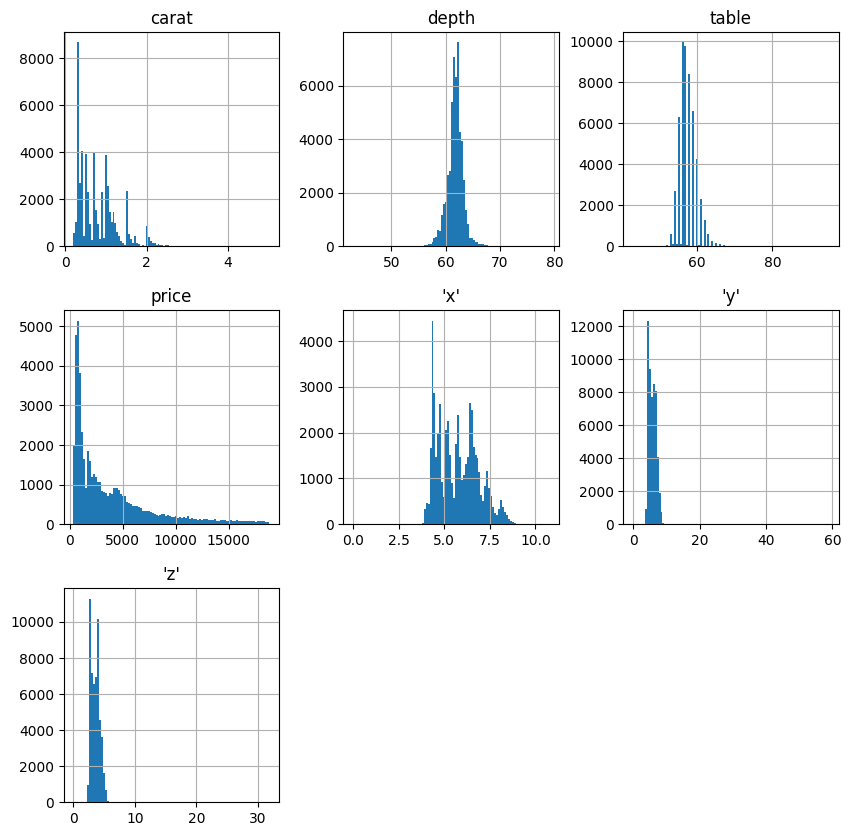

In [20]:
df[["carat","depth","table","price","'x'","'y'","'z'"]].hist(bins=100, figsize=(10,10));

In [21]:
median_carat = df['carat'].median()

df.fillna({'carat': median_carat}, inplace=True)

In [22]:
median_depth = df['depth'].median()

df['depth'].fillna(median_depth, inplace=True)

/tmp/ipython-input-2155475674.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['depth'].fillna(median_depth, inplace=True)


### Задание 1

Заполните пропуски в столбце `y` медианным значением. Чему равно это значение? Ответ округлите до сотых.

In [23]:
median_y = df['\'y\''].median()
print('Мединное значение y: ' + str(median_y))

Мединное значение y: 5.71


In [24]:
df.fillna({'\'y\'': median_y}, inplace=True)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53805 entries, 0 to 53804
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53805 non-null  float64
 1   cut      53805 non-null  object 
 2   color    53805 non-null  object 
 3   clarity  53805 non-null  object 
 4   depth    53805 non-null  float64
 5   table    53805 non-null  float64
 6   price    53805 non-null  float64
 7   'x'      53805 non-null  float64
 8   'y'      53805 non-null  float64
 9   'z'      53805 non-null  float64
dtypes: float64(7), object(3)
memory usage: 4.1+ MB


## Однофакторный анализ

### Число карат

* мелкие — массой до 0,30 карат (не включительно);
* средние — массой от 0,30 до 1 карат (не включительно);
* крупные – 1 карат и выше, называют солитеры.


Небольшие бриллианты различного размера, полученные при огранке алмаза, и весящие каждый в отдельности менее 0,25 карат, называют *melee (мили)*. Полученные таким же путем более крупные бриллианты различного размера называют *melange (меланж)*.


Бриллианты более 6 карат обычно продаются c аукционов.


Алмазам и бриллиантам более 25 карат присваивают собственные имена.

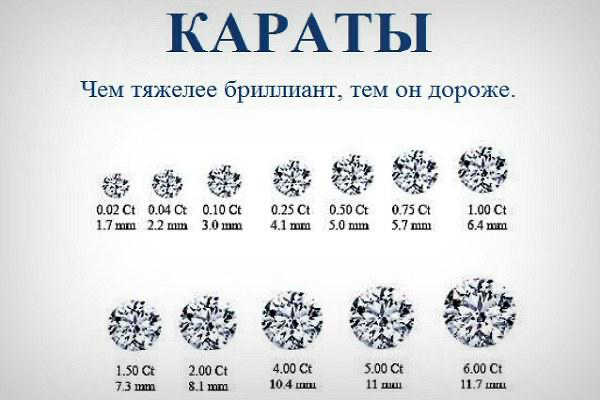

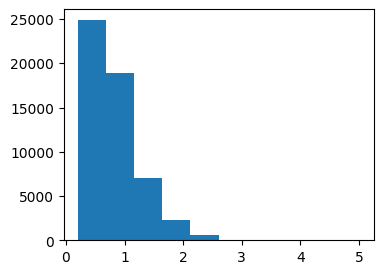

In [26]:
plt.figure(figsize=(4,3))

plt.hist(df.carat);

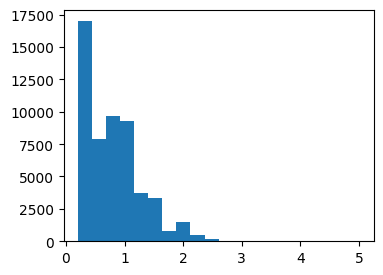

In [27]:
plt.figure(figsize=(4,3))

plt.hist(df.carat, bins=20);

Сколько карат весит самый тяжелый бриллиант в датасете? А самый легкий?

In [28]:
df.carat.min(), df.carat.max()

(0.2, 5.01)

Сколько мелких бриллиантов в датасете?

In [29]:
len(df[df.carat < 0.3])

1582

Сколько процентов бриллиантов среди всего датасета - крупные?

In [30]:
100 * len(df[df.carat >= 1]) / len(df)

35.00046464083264

Посмотрим как число карат влияет на стоимость алмаза

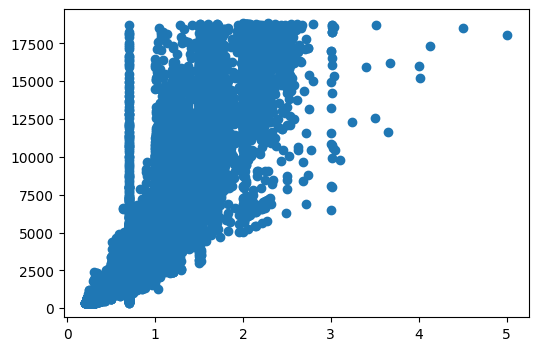

In [31]:
plt.figure(figsize=(6,4))

plt.scatter(df.carat, df.price);

In [32]:
np.corrcoef(df.carat, df.price)[0][1]

np.float64(0.9164989435440223)

### Cut (огранка алмаза)

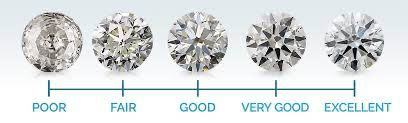

In [33]:
df['cut'].value_counts(normalize=True)

,proportion
cut,
Ideal,0.398941
Premium,0.255088
Very Good,0.224013
Good,0.090772
Fair,0.029700
Goood,0.001487


In [34]:
df['cut'] = df['cut'].replace('Goood', 'Good')

Посмотрим как влияет огранка алмаза на его стоимость

/tmp/ipython-input-1625806102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cut', y='price', data = df, palette='summer')


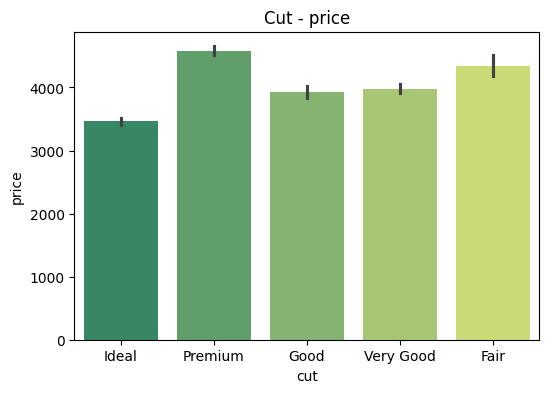

In [35]:
plt.figure(figsize=(6,4))

sns.barplot(x='cut', y='price', data = df, palette='summer')
plt.title('Cut - price')
plt.show();

### Задание 2

Какое максимальное число карат весит алмаз огранки `Fair`?
Ответ округлите до сотых.

In [36]:
# ваш код здесь
df[df.cut == 'Fair'].carat.max()

5.01

Посчитаем среднюю стоимость алмазов в каждой категории

In [37]:
df.groupby('cut')['price'].mean()

,price
cut,
Fair,4347.735294
Good,3926.266317
Ideal,3462.593850
Premium,4581.864918
Very Good,3982.162781


Посчитаем несколько характеристик в зависимости от огранки

In [38]:
df.groupby('cut').agg(PriceMean=('price','mean'),
                      PriceMedian=('price', 'median'),
                      CaratMean=('carat', 'mean'))

,PriceMean,PriceMedian,CaratMean
cut,,,
Fair,4347.735294,3282.0,1.040094
Good,3926.266317,3029.5,0.845796
Ideal,3462.593850,1813.0,0.703331
Premium,4581.864918,3175.0,0.889616
Very Good,3982.162781,2649.0,0.804177


In [39]:
df.groupby('cut').agg(PriceMean=('price','mean'),
                      PriceMedian=('price', 'median'),
                      CaratMean=('carat', 'mean')).sort_values(by='PriceMean', ascending=False)

,PriceMean,PriceMedian,CaratMean
cut,,,
Premium,4581.864918,3175.0,0.889616
Fair,4347.735294,3282.0,1.040094
Very Good,3982.162781,2649.0,0.804177
Good,3926.266317,3029.5,0.845796
Ideal,3462.593850,1813.0,0.703331


## Table and Depth

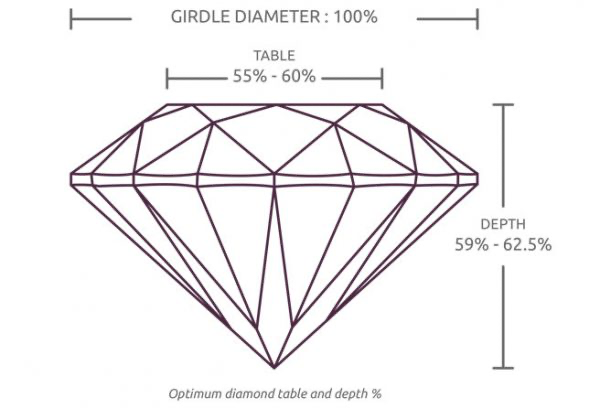

Оптимальное значение параметра `table` для алмаза [55%; 60%].

Какая доля алмазов в данных имеют оптимальное значение `table`?

In [40]:
len(df[(df.table >= 55) & (df.table <= 60)]) / len(df)

0.8439364371340954

### Задание 3

Оптимальное значение параметра `depth` для алмаза [59%; 62.5%].

Какая доля алмазов в данных имеют одновременно оптимальное значение `table` и `depth`?

Ответ округлите до сотых.

In [41]:
# ваш код здесь
optimal_df = df[(df.table >= 55) & (df.table <= 60) & (df.depth >= 59) & (df.depth <= 62.5)]
round(len(optimal_df) / len(df), 2)

0.62

### Задание 4

Сравните медианную стоимость всех алмазов, и алмазов с оптимальными table & depth. Какая больше?

In [42]:
# ваш код здесь
print('Медианная стоимость всех алмазов: ' + str(df.price.median()))
print('Медианная стоимость оптимальных алмазов: ' + str(optimal_df.price.median()))

Медианная стоимость всех алмазов: 2401.0
Медианная стоимость оптимальных алмазов: 2215.0


Вычислите корреляцию `table` и `price`, а затем `depth`и `price`. Какой параметр влияет на цену больше?

In [43]:
np.corrcoef(df.table, df.price)[0][1]

np.float64(0.12662153885758198)

In [44]:
np.corrcoef(df.depth, df.price)[0][1]

np.float64(-0.010831614226837228)

## Clarity - прозрачность алмаза

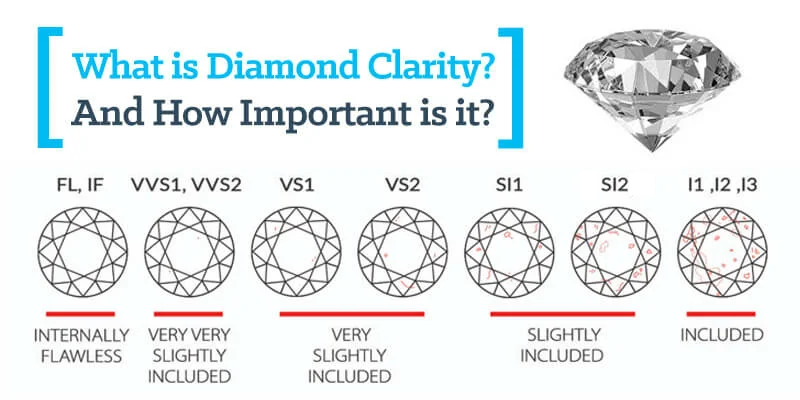

### Задание 5

Сколько различных градаций есть в столбце `clarity`?

In [45]:
# ваш код здесь
df.clarity.unique()

array(['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF'],
      dtype=object)

### Задание 6

Сколько алмазов в таблице, относящихся к категории `very very slightly included`?

In [46]:
# ваш код здесь
len(df[(df.clarity == "VVS1") | (df.clarity == "VVS2")])

8704

### Задание 7

Нарисуйте график зависимости цены алмазов от `clarity`. Алмазы какой категории в наших данных стоят дороже остальных?

/tmp/ipython-input-62671584.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='clarity', y='price', data = df, palette='summer')


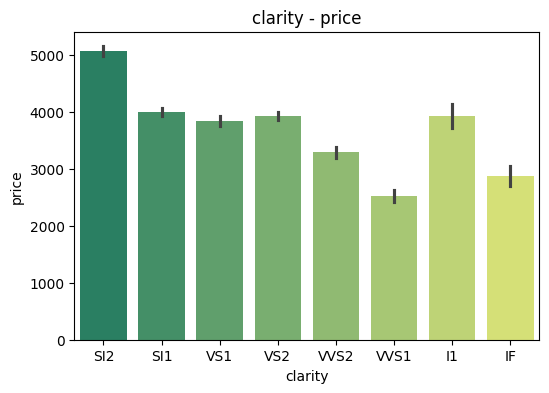

In [47]:
# ваш код здесь
plt.figure(figsize=(6,4))

sns.barplot(x='clarity', y='price', data = df, palette='summer')
plt.title('clarity - price')
plt.show()

### Задание 8

Для каждой пары значений категорий (`cut`,`clarity`) вычислим среднюю и медианную стоимость. Результат отсортируем по убыванию средней стоимости.

Алмазы какой огранки (`cut`) в совокупностью с некоторой категорией `clarity` имеют наибольшую среднюю стоимость?

In [48]:
# ваш код здесь
df.groupby(['cut', 'clarity']).agg(PriceMean=('price','mean'),
                      PriceMedian=('price', 'median')).sort_values(by='PriceMean', ascending=False)

PriceMean  PriceMedian
cut       clarity                          
Premium   SI2      5556.262491       4292.5
Fair      SI2      5145.740175       3681.0
Very Good SI2      4988.709447       4042.0
Ideal     SI2      4761.711917       4068.0
Good      SI2      4544.119816       3763.0
Premium   VS2      4539.441053       2724.0
          VS1      4491.247730       2362.0
          SI1      4451.865244       3618.0
Very Good IF       4373.299625       1708.0
Ideal     I1       4335.726027       3673.5
Good      VS2      4280.315631       3220.5
Very Good VS2      4217.842758       2727.0
Fair      SI1      4201.818182       3511.0
          VS2      4189.217054       3202.5
          VS1      4165.141176       2829.5
Good      IF       4141.931507       1806.0
Very Good I1       4078.226190       3283.0
Premium   I1       3947.331707       3261.0
Very Good SI1      3936.972136       2810.0
Fair      VVS1     3871.352941       2797.0
Premium   IF       3856.143478       1148.0
Very Good VS1      3805.480813       2326.5
Good      VS1      3799.741248       2427.0
Premium   VVS2     3784.643599       1334.0
Ideal     SI1      3755.110434       2537.0
Fair      I1       3703.533333       2397.0
Good      SI1      3688.387015       2723.0
          I1       3601.810526       3127.0
Ideal     VS1      3490.985179       1815.0
Fair      VVS2     3349.768116       2484.0
Ideal     VS2      3290.504851       1689.0
          VVS2     3256.055212       1334.0
Good      VVS2     3118.108108       1866.5
Very Good VVS2     3037.394652       1032.0
Premium   VVS1     2834.611382       1115.0
Ideal     VVS1     2474.090240       1114.0
Very Good VVS1     2451.883249        941.0
Ideal     IF       2279.618257       1020.0
Good      VVS1     2272.391534        977.0
Fair      IF       1912.333333       1849.0

## Pandas profiling

In [49]:
# !pip install ydata_profiling
!pip install https://github.com/pandas-profiling/pandas-profiling/archive/master.zip -q

     | 17.9 MB 23.0 MB/s 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.3 MB/s eta 0:00:00


In [50]:
from ydata_profiling import ProfileReport

In [51]:
df_copy = pd.read_csv(DIAMONDS_DATASET)

profile_report = ProfileReport(df_copy, title='Pandas Profiling Report')

In [52]:
profile_report

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 10.18it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [53]:
profile_report.to_file('Diamonds_report.html')

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# Домашнее задание

## 1) x, y, z

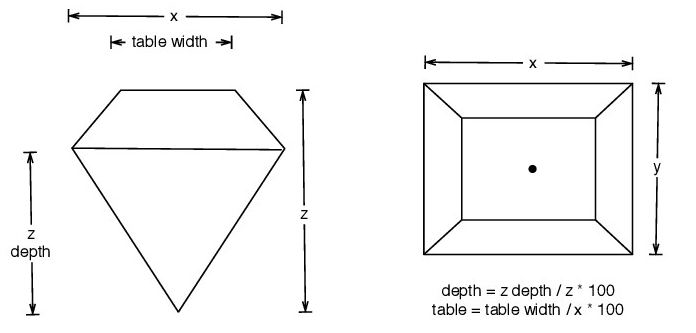

In [54]:
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', ''x'',
       ''y'', ''z''],
      dtype='object')

Переименуем колонки

In [55]:
df = df.rename(columns={"'x'" : 'x', "'y'" : 'y', "'z'" : 'z'})
df.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')

### Задание 1

Для каждого из трех столбцов (`x`, `y`, `z`) вычислите медианное значение. В ответ запишите максимальное из полученных чисел без округлений.

In [56]:
# ваш код здесь
max(df['x'].median(), df['y'].median(), df['z'].median())

5.71

Для каждого из этих столбцов вычислите минимальное значение.

In [57]:
np.min(df['x']), np.min(df['y']), np.min(df['z'])

(0.0, 0.0, 0.0)

Нулевые размеры - явно ошибки.

### Задание 2

Выведите на экран все строки таблицы (только столбцы `x`,`y`,`z`), в которых хотя бы одна из координат равна нулю.

Сколько таких строк?

In [58]:
# ваш код здесь
df[(df.x == 0) | (df.y == 0) | (df.z == 0)]

,carat,cut,color,clarity,depth,table,price,x,y,z
2201,1.00,Premium,G,SI2,59.1,59.0,3142.0,6.55,6.48,0.0
2308,1.01,Premium,H,I1,58.1,59.0,3167.0,6.66,6.60,0.0
4779,1.10,Premium,G,SI2,63.0,59.0,3696.0,6.50,6.47,0.0
5458,1.01,Premium,F,SI2,59.2,58.0,3837.0,6.50,6.47,0.0
10146,1.50,Good,G,I1,64.0,61.0,4731.0,7.15,7.04,0.0
11158,1.07,Ideal,F,SI2,61.6,56.0,4954.0,0.00,6.62,0.0
11937,1.00,Very Good,H,VS2,63.3,53.0,5139.0,0.00,0.00,0.0
13572,1.15,Ideal,G,VS2,59.2,56.0,5564.0,6.88,6.83,0.0
15916,1.14,Fair,G,VS1,57.5,67.0,6381.0,0.00,0.00,0.0
24342,2.18,Premium,H,SI2,59.4,61.0,12631.0,8.49,8.45,0.0


In [59]:
print('Количество строк: ' + str(len(df[(df.x == 0) | (df.y == 0) | (df.z == 0)])))

Количество строк: 19


### Задание 3

Удалите из таблицы эти строки. Сколько строк осталось в таблице?

In [60]:
# ваш код здесь
old_df = df
df = df[(df.x != 0) & (df.y != 0) & (df.z != 0)]
np.min(df['x']), np.min(df['y']), np.min(df['z'])

(3.73, 3.68, 1.07)

In [61]:
print('Осталось строк: ' + str(len(df)))

Осталось строк: 53786


### Задание 4

Вычислите корреляцию между каждым из этих столбцов и `price`. Какой столбец коррелирует с ценой алмаза больше всего?

In [62]:
# ваш код здесь
x_price_core = df.corr(numeric_only=True)['price']
x_price_core

,price
carat,0.916492
depth,-0.010928
table,0.126722
price,1.000000
x,0.887183
y,0.867665
z,0.868089


### Задание 5

Постройте scatter-plot для отражения зависимости между ценой алмаза и координатой, наиболее с ней коррелирующей. На какую зависимость она больше всего похожа?

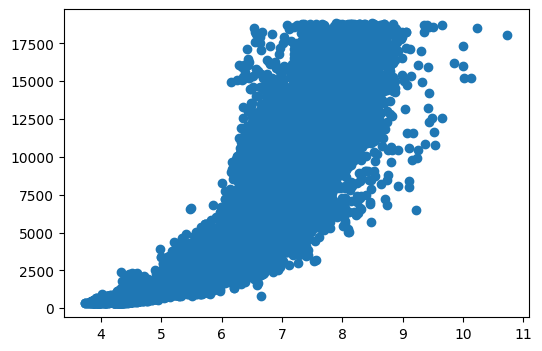

In [63]:
# ваш код здесь
plt.figure(figsize=(6,4))

plt.scatter(df.x, df.price)

### Задание 6

Какой процент среди всех алмазов имеет `x` и `y` размеры, превышающие средние значения (по `x` и `y`)? Ответ округлите до целого числа.

In [64]:
# ваш код здесь
x_mean = df['x'].mean()
y_mean = df['y'].mean()

round(len(df[(df.x > x_mean) & (df.y > y_mean)]) / len(df) * 100)

47

### Задание 7

Какая доля среди крупных алмазов имеет `z`-размеры, меньшие медианного? Ответ округлите до четырех знаков после запятой.

In [65]:
# ваш код здесь
z_median = df['z'].median()
round(len(df[df.z < z_median]) / len(df) * 100, 4)

49.9572

## 2) Color

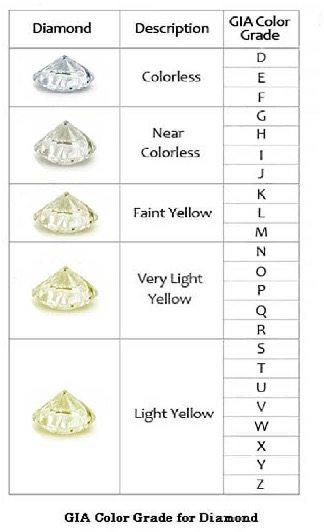

### Задание 8

К каким категориям (Description) из градации выше относятся алмазы в данных?

In [66]:
# ваш код здесь
def get_description(color):
  match color:
    case 'D' | 'E' | 'F':
        return 'Colorless'
    case 'G' | 'H' | 'I' | 'J':
        return 'Near Colorless'
    case 'K' | 'L' | 'M':
        return 'Faint Yellow'
    case 'N' | 'O' | 'P' | 'Q' | 'R':
        return 'Very Light Yellow'
    case _:
        return 'Light Yellow'

In [67]:
df = df.copy()
df['description'] = df['color'].apply(get_description)

df['description'].unique()

array(['Colorless', 'Near Colorless'], dtype=object)

### Задание 9

Нарисуйте график, отражающий зависимость стоимости алмазов от его категории цвета.

Алмазы какого цвета стоят дороже остальных?

/tmp/ipython-input-1741877154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='description', y='price', data = df, palette='summer')


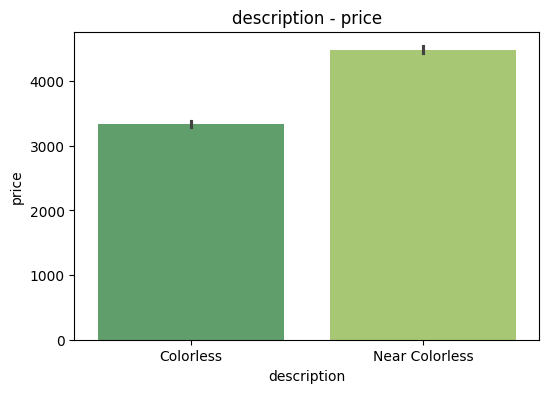

In [68]:
# ваш код здесь
plt.figure(figsize=(6,4))

sns.barplot(x='description', y='price', data = df, palette='summer')
plt.title('description - price')
plt.show()

### Задание 10

Для каждого цвета алмаза вычислите медианную стоимость и медианный вес (в каратах). Отсортируйте полученную при помощи groupby таблицу по убыванию медианной стоимости.

Верно ли, что при убывании PriceMedian, сгруппированной по цвету, CaratMedian также убывает? (не возрастает)

In [69]:
# ваш код здесь
df.groupby(['color']).agg(
    PriceMedian=('price','median'),
    CaratMedian=('carat', 'median')).sort_values(by='PriceMedian', ascending=False)

,PriceMedian,CaratMedian
color,,
J,4234.5,1.11
I,3721.5,1.00
H,3449.5,0.90
F,2345.0,0.70
G,2242.0,0.70
D,1842.0,0.54
E,1741.0,0.54


### Задание 11

Вычислите среднюю стоимость алмазов по каждой тройке категорий (`cut`,`color`,`clarity`). Какие алмазы дороже остальных?

В ответе запишите тройку названий в скобках через запятую, без кавычек и пробелов. Например, (Premium,D,IF)

In [70]:
# ваш код здесь
res = df.groupby(['cut', 'color', 'clarity']).agg(
    PriceMean=('price','mean')).sort_values(by='PriceMean', ascending=False).head(3)

In [71]:
for idx in res.index:
    print(f"({idx[0]}, {idx[1]}, {idx[2]})")

(Very Good, D, IF)
(Good, D, IF)
(Ideal, J, I1)


In [72]:
df.to_csv('/content/drive/MyDrive/data/eda/diamonds_clean_data.csv', index=False)

# Data Encoding


In [73]:
data_file = '/content/drive/MyDrive/data/eda/diamonds_clean_data.csv'

In [74]:
df = pd.read_csv(data_file)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53786 entries, 0 to 53785
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   carat        53786 non-null  float64
 1   cut          53786 non-null  object 
 2   color        53786 non-null  object 
 3   clarity      53786 non-null  object 
 4   depth        53786 non-null  float64
 5   table        53786 non-null  float64
 6   price        53786 non-null  float64
 7   x            53786 non-null  float64
 8   y            53786 non-null  float64
 9   z            53786 non-null  float64
 10  description  53786 non-null  object 
dtypes: float64(7), object(4)
memory usage: 4.5+ MB


### Уникальные значения color

In [76]:
print(df["color"].unique())
print(df.value_counts(["color"]))

['E' 'I' 'J' 'H' 'F' 'G' 'D']
color
G        11256
E         9777
F         9518
H         8270
D         6755
I         5408
J         2802
Name: count, dtype: int64


### Уникальные значения cut

In [77]:
print(df["cut"].unique())
print(df.value_counts(["cut"]))

['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']
cut      
Ideal        21462
Premium      13714
Very Good    12052
Good          4961
Fair          1597
Name: count, dtype: int64


### Уникальные значения clarity

In [82]:
print(df["clarity"].unique())
print(df.value_counts(["clarity"]))

['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']
clarity
SI1        13033
VS2        12227
SI2         9146
VS1         8156
VVS2        5056
VVS1        3647
IF          1784
I1           737
Name: count, dtype: int64


### Кодирование Cut

In [94]:
df_encoded = df.copy()

In [95]:
cut_order = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
df_encoded['cut_encoded'] = df_encoded['cut'].map(cut_order)
df_encoded = df_encoded.drop(['cut'], axis=1)

In [96]:
df_encoded.head(5)

,carat,color,clarity,depth,table,price,x,y,z,description,cut_encoded
0,0.23,E,SI2,61.5,55.0,326.0,3.95,3.98,2.43,Colorless,4
1,0.21,E,SI1,59.8,61.0,326.0,3.89,3.84,2.31,Colorless,3
2,0.23,E,VS1,56.9,65.0,327.0,4.05,4.07,2.31,Colorless,1
3,0.29,I,VS2,62.4,58.0,334.0,4.20,4.23,2.63,Near Colorless,3
4,0.31,J,SI2,63.3,58.0,335.0,4.34,4.35,2.75,Near Colorless,1


In [97]:
print(df_encoded["cut_encoded"].unique())
print(df_encoded.value_counts(["cut_encoded"]))

[4 3 1 2 0]
cut_encoded
4              21462
3              13714
2              12052
1               4961
0               1597
Name: count, dtype: int64


### Кодирование clarity

In [98]:
clarity_order = {'IF': 1, 'VVS2': 2, 'VVS1': 2, 'VS1': 3, 'VS2': 4, 'SI1': 5, 'SI2': 6, 'I1': 7}
df_encoded['clarity_encoded'] = df_encoded['clarity'].map(clarity_order)
df_encoded = df_encoded.drop(['clarity'], axis=1)

In [99]:
df_encoded.head(5)

,carat,color,depth,table,price,x,y,z,description,cut_encoded,clarity_encoded
0,0.23,E,61.5,55.0,326.0,3.95,3.98,2.43,Colorless,4,6
1,0.21,E,59.8,61.0,326.0,3.89,3.84,2.31,Colorless,3,5
2,0.23,E,56.9,65.0,327.0,4.05,4.07,2.31,Colorless,1,3
3,0.29,I,62.4,58.0,334.0,4.20,4.23,2.63,Near Colorless,3,4
4,0.31,J,63.3,58.0,335.0,4.34,4.35,2.75,Near Colorless,1,6


In [100]:
print(df_encoded["clarity_encoded"].unique())
print(df_encoded.value_counts(["clarity_encoded"]))

[6 5 3 4 2 7 1]
clarity_encoded
5                  13033
4                  12227
6                   9146
2                   8703
3                   8156
1                   1784
7                    737
Name: count, dtype: int64


### Кодирование color

In [85]:
from sklearn.preprocessing import OneHotEncoder

In [101]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
color_encoded = ohe.fit_transform(df_encoded[['color']])
one_hot_df = pd.DataFrame(color_encoded, columns=ohe.get_feature_names_out(['color']))
df_encoded = pd.concat([df_encoded, one_hot_df], axis=1)
df_encoded = df_encoded.drop(['color'], axis=1)

In [102]:
df_encoded.head(5)

,carat,depth,table,price,x,y,z,description,cut_encoded,clarity_encoded,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,0.23,61.5,55.0,326.0,3.95,3.98,2.43,Colorless,4,6,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.21,59.8,61.0,326.0,3.89,3.84,2.31,Colorless,3,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.23,56.9,65.0,327.0,4.05,4.07,2.31,Colorless,1,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.29,62.4,58.0,334.0,4.20,4.23,2.63,Near Colorless,3,4,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.31,63.3,58.0,335.0,4.34,4.35,2.75,Near Colorless,1,6,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [106]:
df_encoded = df_encoded.drop(['description'], axis=1)

# Correlation, Heat Map

In [104]:
import seaborn as sns

In [110]:
corr_m = df_encoded.corr()

<Axes: >

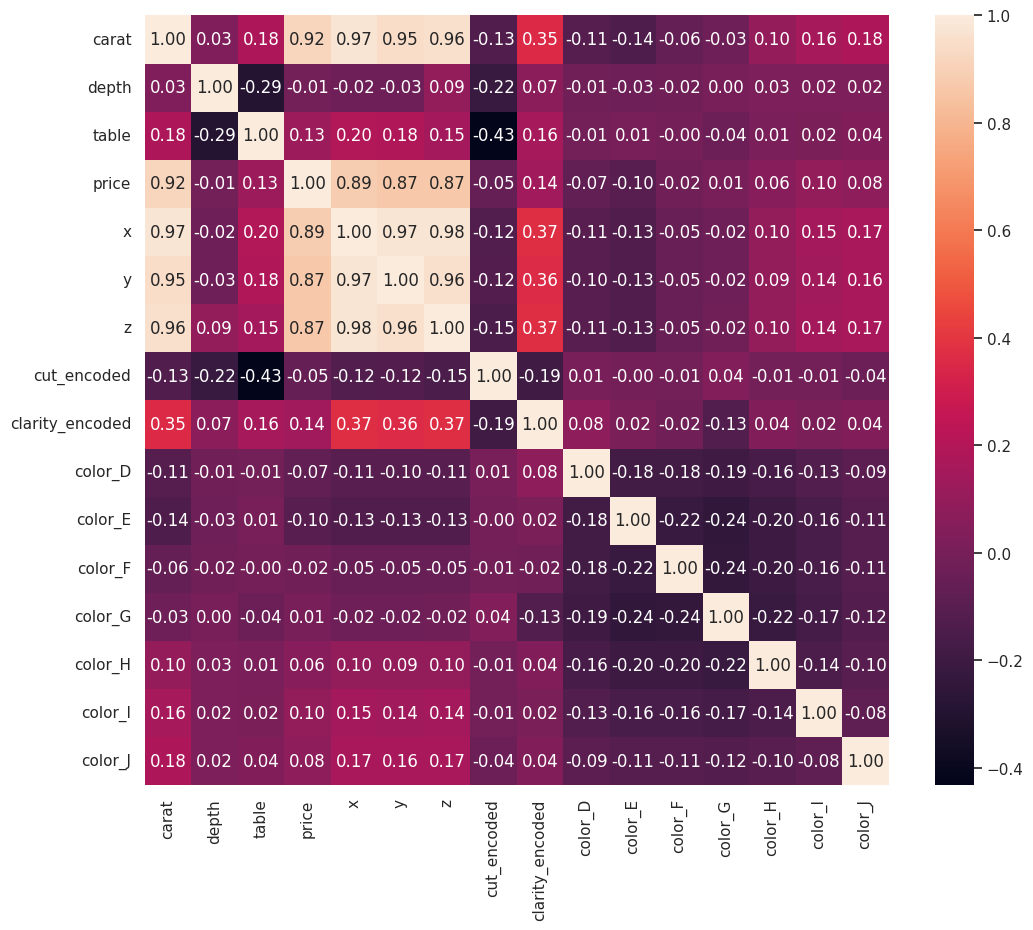

In [122]:
sns.set( rc={"figure.figsize": (12,10)})
sns.heatmap(corr_m, annot=True, fmt='.2f')

<Axes: >

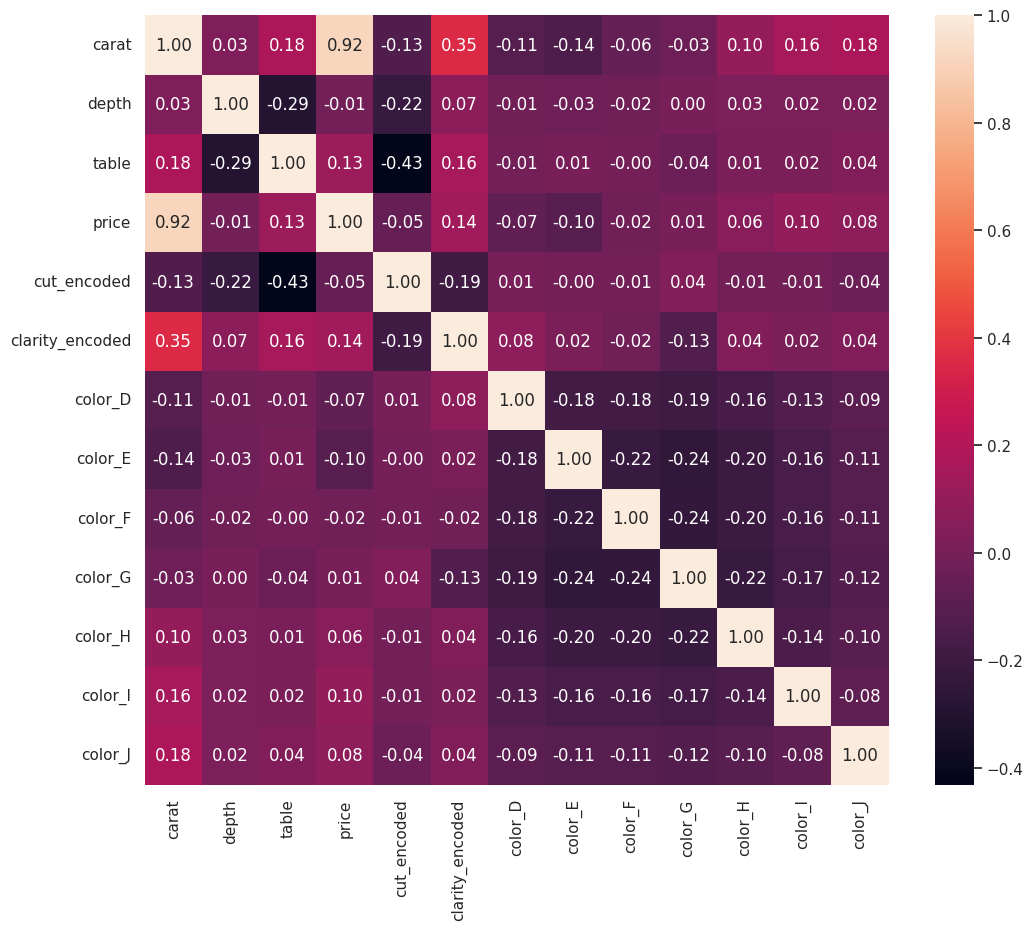

In [130]:
sns.set( rc={"figure.figsize": (12,10)})
sns.heatmap(df_encoded.drop(['x','y','z'], axis=1).corr(), annot=True, fmt='.2f')

<Axes: >

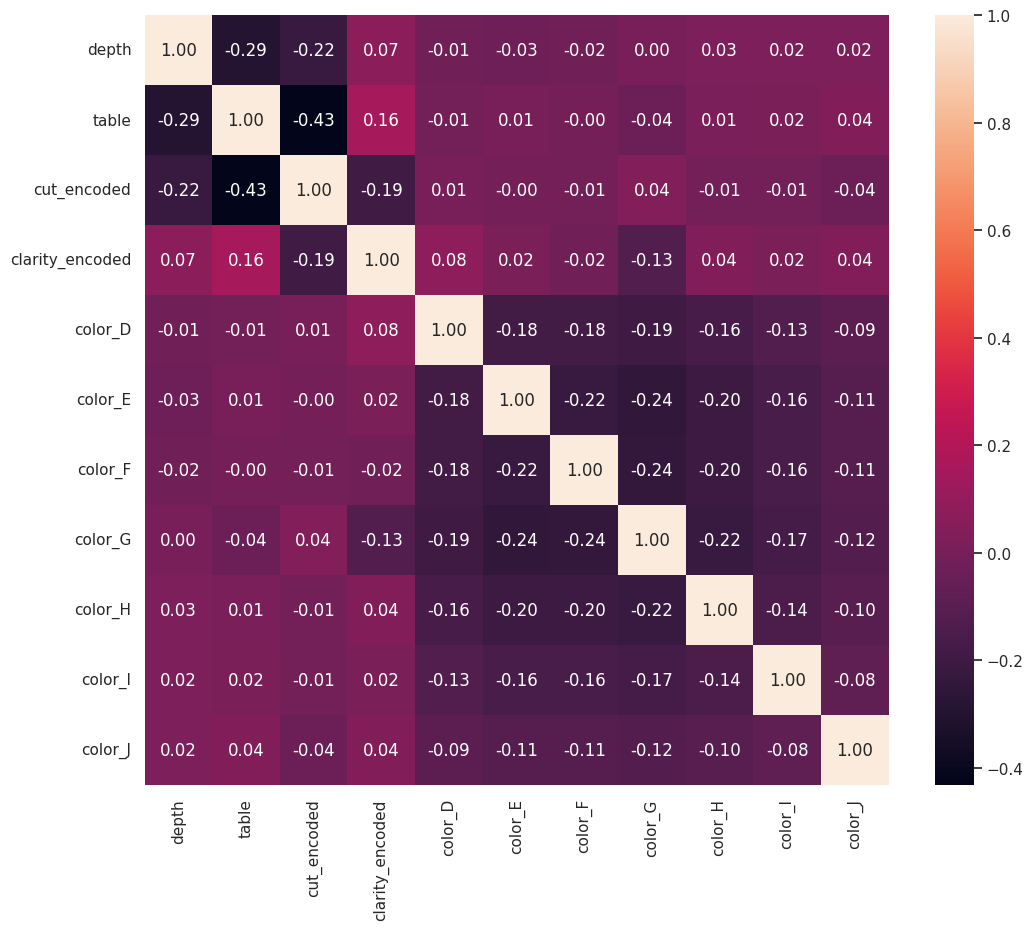

In [132]:
sns.set( rc={"figure.figsize": (12,10)})
sns.heatmap(df_encoded.drop(['x','y','z', 'price', 'carat'], axis=1).corr(), annot=True, fmt='.2f')

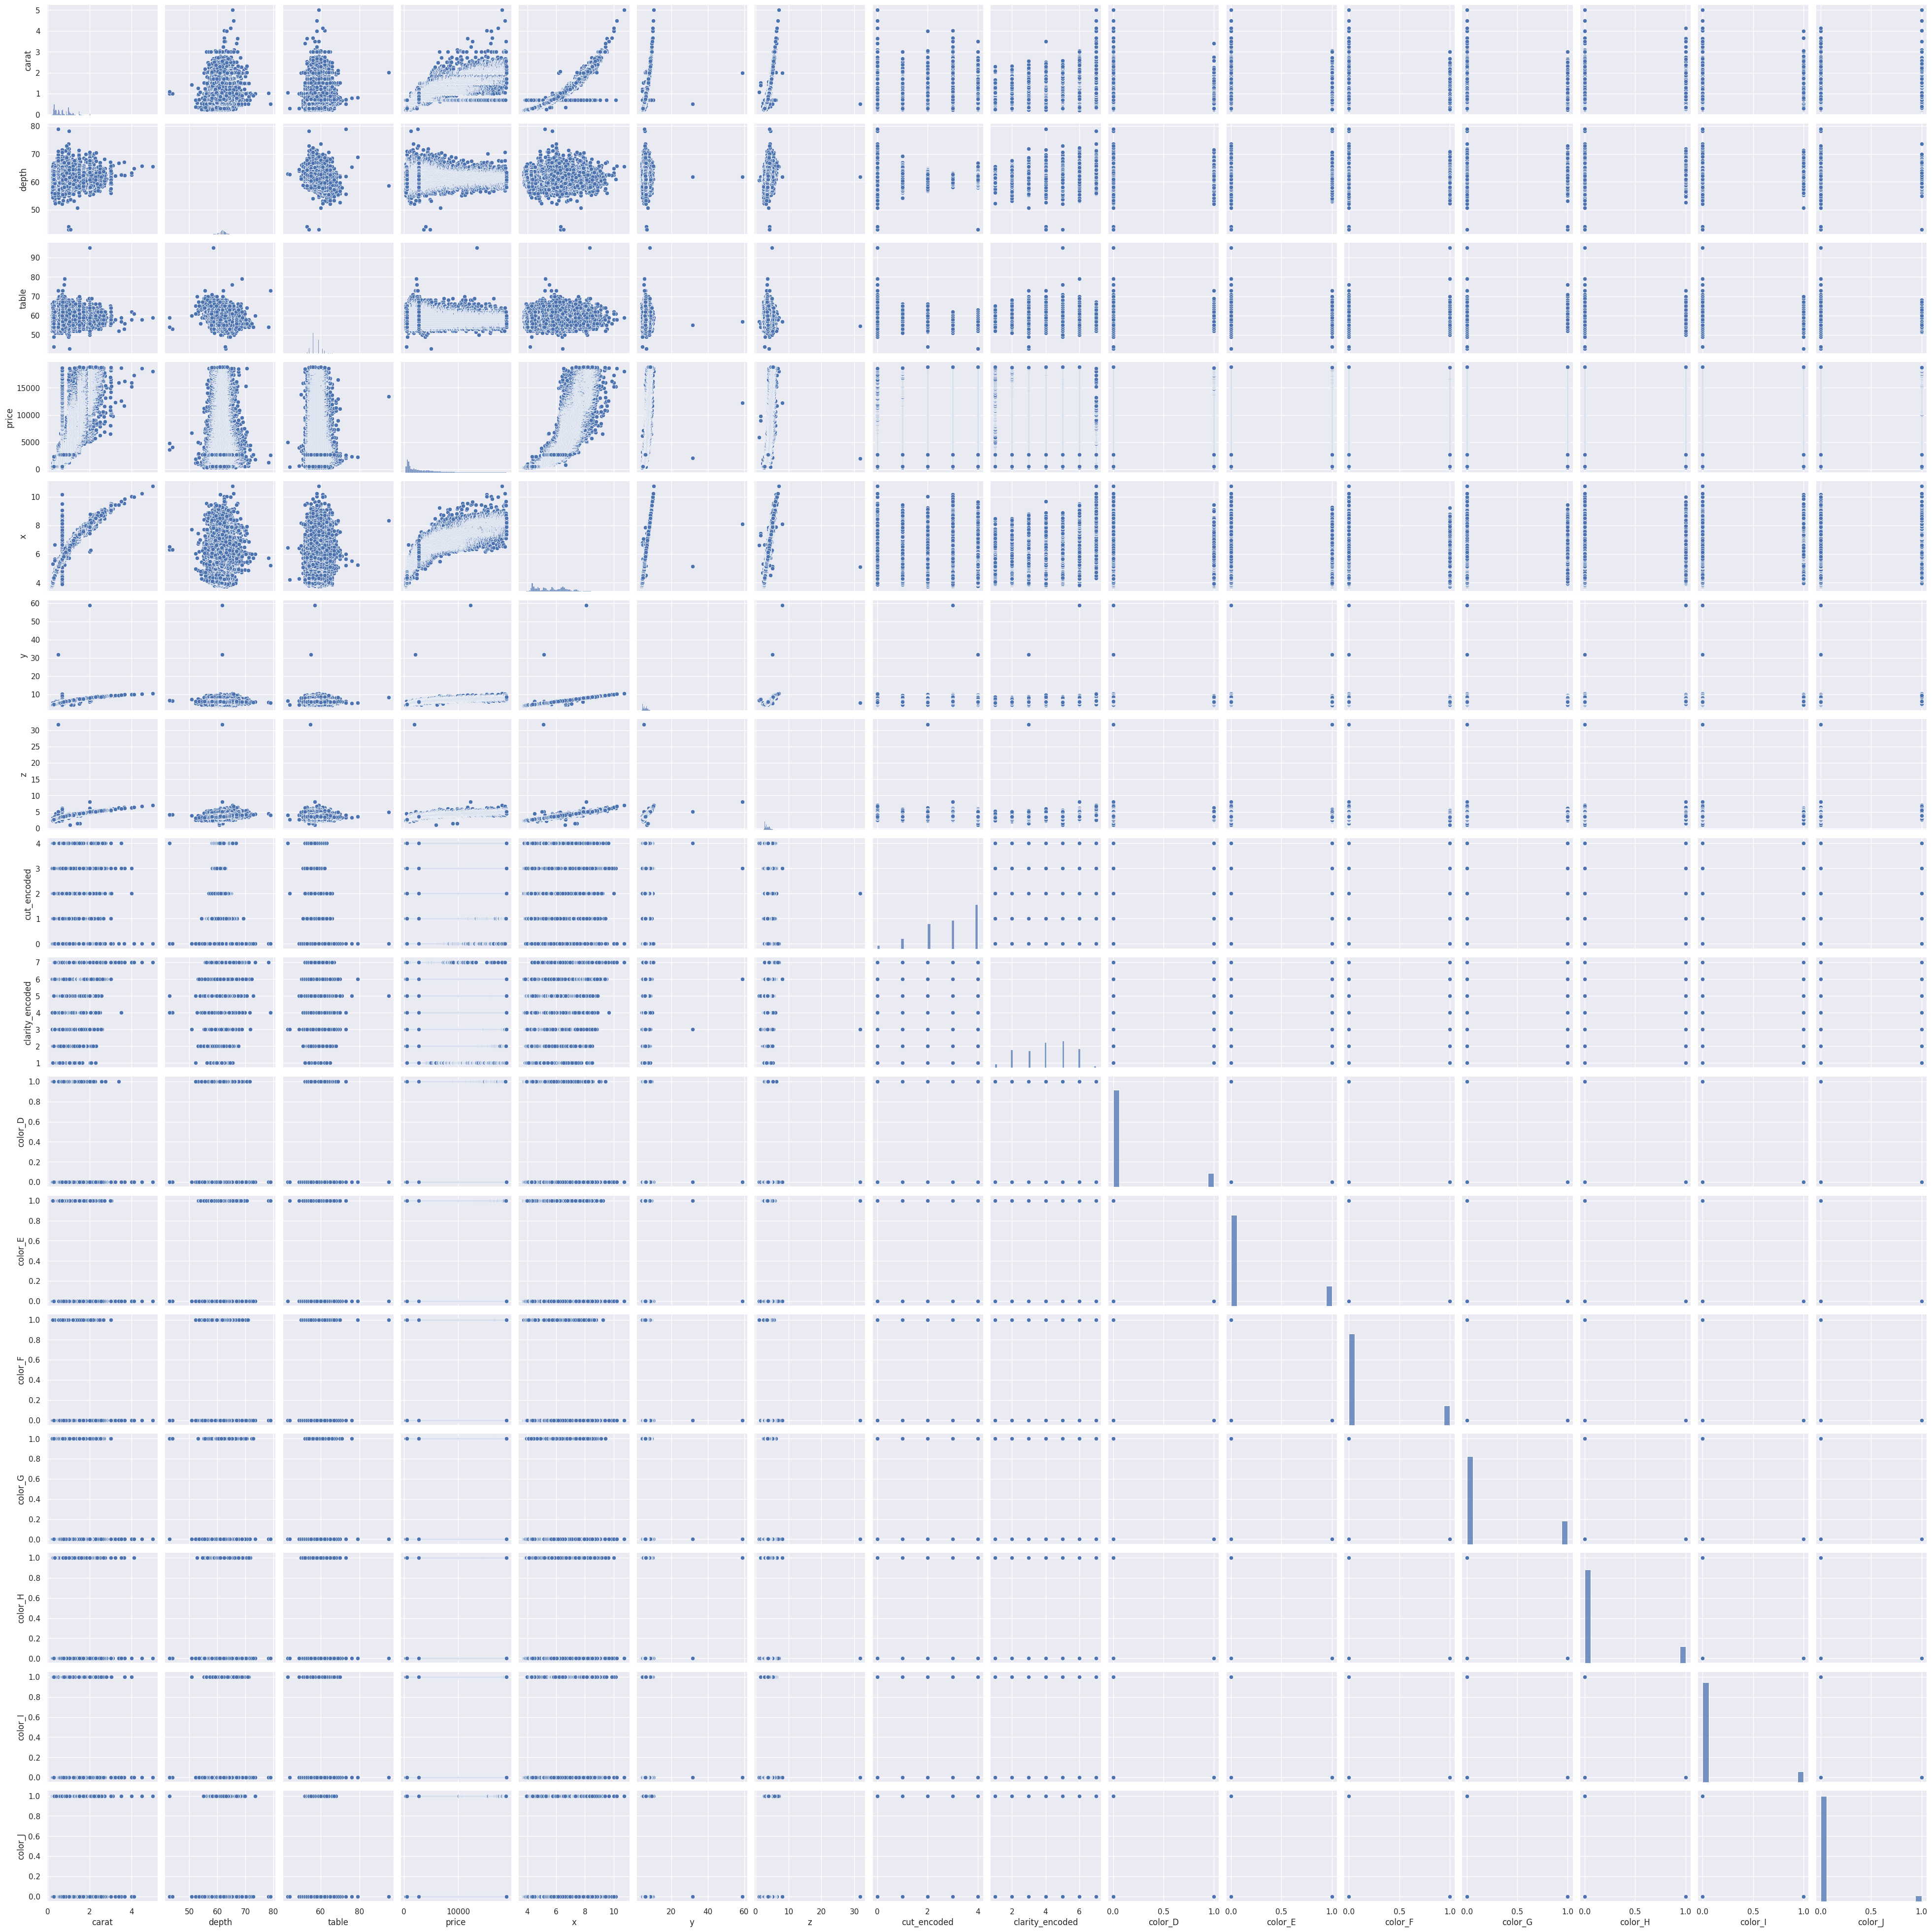

In [124]:
sns.pairplot(df_encoded)
plt.show()

# Важность параметров

In [127]:
x = df_encoded.drop(columns=['price'])
y = df_encoded['price']

In [128]:
x.head(5)

,carat,depth,table,x,y,z,cut_encoded,clarity_encoded,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,0.23,61.5,55.0,3.95,3.98,2.43,4,6,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.21,59.8,61.0,3.89,3.84,2.31,3,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.23,56.9,65.0,4.05,4.07,2.31,1,3,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.29,62.4,58.0,4.20,4.23,2.63,3,4,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.31,63.3,58.0,4.34,4.35,2.75,1,6,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [129]:
y.head(5)

,price
0,326.0
1,326.0
2,327.0
3,334.0
4,335.0


## RandomForest

In [133]:
from sklearn.ensemble import RandomForestRegressor

In [135]:
rf = RandomForestRegressor(n_estimators=100, random_state=43)
rf.fit(x, y)

RandomForestRegressor(random_state=43)

In [137]:
feature_importances_series = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
feature_importances_series

,Feature,Importance
4,y,0.865453
7,clarity_encoded,0.062332
0,carat,0.015498
14,color_J,0.010907
3,x,0.010309
13,color_I,0.007830
5,z,0.006436
12,color_H,0.005619
1,depth,0.003124
8,color_D,0.002781


### Permutation importance

In [139]:
from sklearn.inspection import permutation_importance

res = permutation_importance(rf, x, y, n_repeats=10, n_jobs=-1, random_state=35)

In [142]:
ir = res.importances_mean.argsort()[::-1]
for i in ir:
  print(f'{x.columns[i]}: {res.importances_mean[i]:.3f} std {res.importances_std[i]:.3f}')

y: 1.219 std 0.004
clarity_encoded: 0.167 std 0.001
carat: 0.055 std 0.001
color_J: 0.041 std 0.000
color_I: 0.033 std 0.000
x: 0.033 std 0.000
z: 0.027 std 0.000
color_H: 0.019 std 0.000
color_D: 0.013 std 0.000
color_G: 0.010 std 0.000
color_E: 0.008 std 0.000
color_F: 0.008 std 0.000
depth: 0.004 std 0.000
table: 0.003 std 0.000
cut_encoded: 0.003 std 0.000


## GradientBoosting

In [143]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=43)
gb.fit(x, y)

GradientBoostingRegressor(random_state=43)

In [145]:
feature_importances_series = pd.DataFrame({
    'Feature': x.columns,
    'Importance': gb.feature_importances_
}).sort_values(by='Importance', ascending=False)
feature_importances_series

,Feature,Importance
4,y,0.800098
5,z,0.097311
7,clarity_encoded,0.060202
3,x,0.011101
14,color_J,0.009160
0,carat,0.008578
13,color_I,0.005610
8,color_D,0.002046
10,color_F,0.001777
12,color_H,0.001547


### Permutation importance

In [146]:
res_gb = permutation_importance(gb, x, y, n_repeats=10, n_jobs=-1, random_state=35)

In [147]:
ir = res_gb.importances_mean.argsort()[::-1]
for i in ir:
  print(f'{x.columns[i]}: {res_gb.importances_mean[i]:.3f} std {res_gb.importances_std[i]:.3f}')

y: 0.972 std 0.004
z: 0.134 std 0.001
clarity_encoded: 0.134 std 0.001
x: 0.025 std 0.000
color_J: 0.021 std 0.000
carat: 0.016 std 0.000
color_I: 0.011 std 0.000
color_D: 0.007 std 0.000
color_E: 0.004 std 0.000
color_H: 0.003 std 0.000
color_F: 0.003 std 0.000
cut_encoded: 0.001 std 0.000
color_G: 0.001 std 0.000
depth: 0.000 std 0.000
table: 0.000 std 0.000


## LinearRegression

In [148]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [149]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [150]:
lr = LinearRegression()
lr.fit(x_scaled, y)

LinearRegression()

In [152]:
feature_importances_series = pd.DataFrame({
    'Feature': x.columns,
    'Coeff': lr.coef_,
    'Coeff_abs': np.abs(lr.coef_)
}).sort_values(by='Coeff_abs', ascending=False)
feature_importances_series

,Feature,Coeff,Coeff_abs
0,carat,4191.874103,4191.874103
7,clarity_encoded,-842.689755,842.689755
14,color_J,-361.034649,361.034649
13,color_I,-226.121564,226.121564
8,color_D,212.713997,212.713997
9,color_E,161.483733,161.483733
6,cut_encoded,128.272757,128.272757
12,color_H,-123.964074,123.964074
10,color_F,115.603416,115.603416
3,x,-94.278307,94.278307


### Permutation importance

In [155]:
res_lr = permutation_importance(lr, x_scaled, y, n_repeats=10, n_jobs=-1, random_state=35)

In [156]:
ir = res_lr.importances_mean.argsort()[::-1]
for i in ir:
  print(f'{x.columns[i]}: {res_lr.importances_mean[i]:.3f} std {res_lr.importances_std[i]:.3f}')

carat: 2.212 std 0.008
clarity_encoded: 0.089 std 0.001
color_J: 0.016 std 0.000
color_I: 0.007 std 0.000
color_D: 0.006 std 0.000
color_E: 0.003 std 0.000
cut_encoded: 0.002 std 0.000
color_H: 0.002 std 0.000
color_F: 0.002 std 0.000
x: 0.001 std 0.000
y: 0.001 std 0.000
depth: 0.000 std 0.000
table: 0.000 std 0.000
z: 0.000 std 0.000
color_G: 0.000 std 0.000


# Обучение моделей

In [157]:
from sklearn.model_selection import train_test_split

In [170]:
df_two_features = df_encoded[['price', 'y', 'clarity_encoded']]
df_three_features = df_encoded[['price', 'cut_encoded', 'carat', 'clarity_encoded']]

## RandomForest

In [167]:
def get_data(cur_df):
  x = cur_df.drop('price', axis=1)
  y = cur_df['price']

  y_bins = pd.qcut(y, q=10, labels=False)  # 10 квантилей

  x_train, x_test, y_train, y_test = train_test_split(
      x, y, test_size=0.3, random_state=42, stratify=y_bins)

  return x_train, x_test, y_train, y_test

### Features 'y' and 'clarity'

In [171]:
x_train, x_test, y_train, y_test = get_data(df_two_features)

In [172]:
rf = RandomForestRegressor(n_estimators=100, random_state=43)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=43)

In [173]:
from sklearn.metrics import mean_absolute_percentage_error

y_pred = rf.predict(x_test)
print('RandomForest mape = ' + str(mean_absolute_percentage_error(y_test, y_pred)))

RandomForest mape = 0.14976643542313733


### Features 'cut' and 'carat' and 'clarity'

In [174]:
x_train, x_test, y_train, y_test = get_data(df_three_features)

In [175]:
rf = RandomForestRegressor(n_estimators=100, random_state=43)
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=43)

In [176]:
y_pred = rf.predict(x_test)
print('RandomForest mape = ' + str(mean_absolute_percentage_error(y_test, y_pred)))

RandomForest mape = 0.14991217960218992


## Linear Regression

In [177]:
def get_data_scaled(cur_df):
  x = cur_df.drop('price', axis=1)
  y = cur_df['price']

  scaler = StandardScaler()
  x_scaled = scaler.fit_transform(x)

  y_bins = pd.qcut(y, q=10, labels=False)  # 10 квантилей

  x_train, x_test, y_train, y_test = train_test_split(
      x_scaled, y, test_size=0.3, random_state=42, stratify=y_bins)

  return x_train, x_test, y_train, y_test

### Features 'y' and 'clarity'

In [178]:
x_train, x_test, y_train, y_test = get_data_scaled(df_two_features)

In [179]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [180]:
y_pred = lr.predict(x_test)
print('Linear regression mape = ' + str(mean_absolute_percentage_error(y_test, y_pred)))

Linear regression mape = 0.6133900644499386


### Features 'cut' and 'carat' and 'clarity'

In [181]:
x_train, x_test, y_train, y_test = get_data_scaled(df_three_features)

In [182]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [183]:
y_pred = lr.predict(x_test)
print('Linear regression mape = ' + str(mean_absolute_percentage_error(y_test, y_pred)))

Linear regression mape = 0.4462371784208873


# Итог
Наилучшим образом себя показала линейная регрессия на параметрах y + clarity